<a href="https://colab.research.google.com/github/xtianu/Docencia/blob/main/UT/Test/Tirana_CV_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

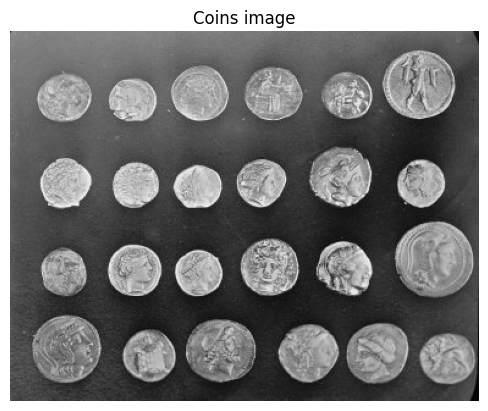

Image size (shape): (303, 384)
Pixel grayscale level range: min = 1 , max = 252


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_uint
from skimage.util import random_noise
from skimage.filters import gaussian, prewitt, median
from skimage.data import binary_blobs
from skimage.morphology import erosion, disk
from skimage.color import rgb2gray
from scipy import ndimage
import math

# load the image
coins = data.coins()
plt.imshow(coins, cmap='gray')
plt.title('Coins image')
plt.axis('off')
plt.show() # show the image

print("Image size: ", coins.shape)
print("Pixel grayscale level range: min =", coins.min(), ", max =", coins.max())

## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

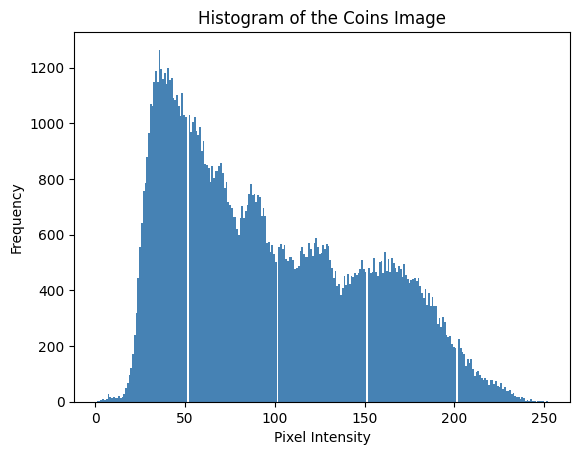

In [3]:
# Creating and showing the histogram
# Metrics used: Pixel Intensity, Frequency

plt.hist(coins.ravel(), bins=256, facecolor='steelblue')
plt.title('Histogram of the Coins Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

The histogram of the coins image shows three main peaks. The first peak at low intensity values corresponds to the dark background of the image, which occupies most of the image area. The second peak at mid-range values represents the coin surfaces themselves, which reflect a moderate amount of light and appear as medium gray tones. The third peak at higher intensity values corresponds to the bright edges and raised details on the coins, where light hits directly and creates strong reflections.

## 3. Applied noise to the image and use the correct function to erase the noise.

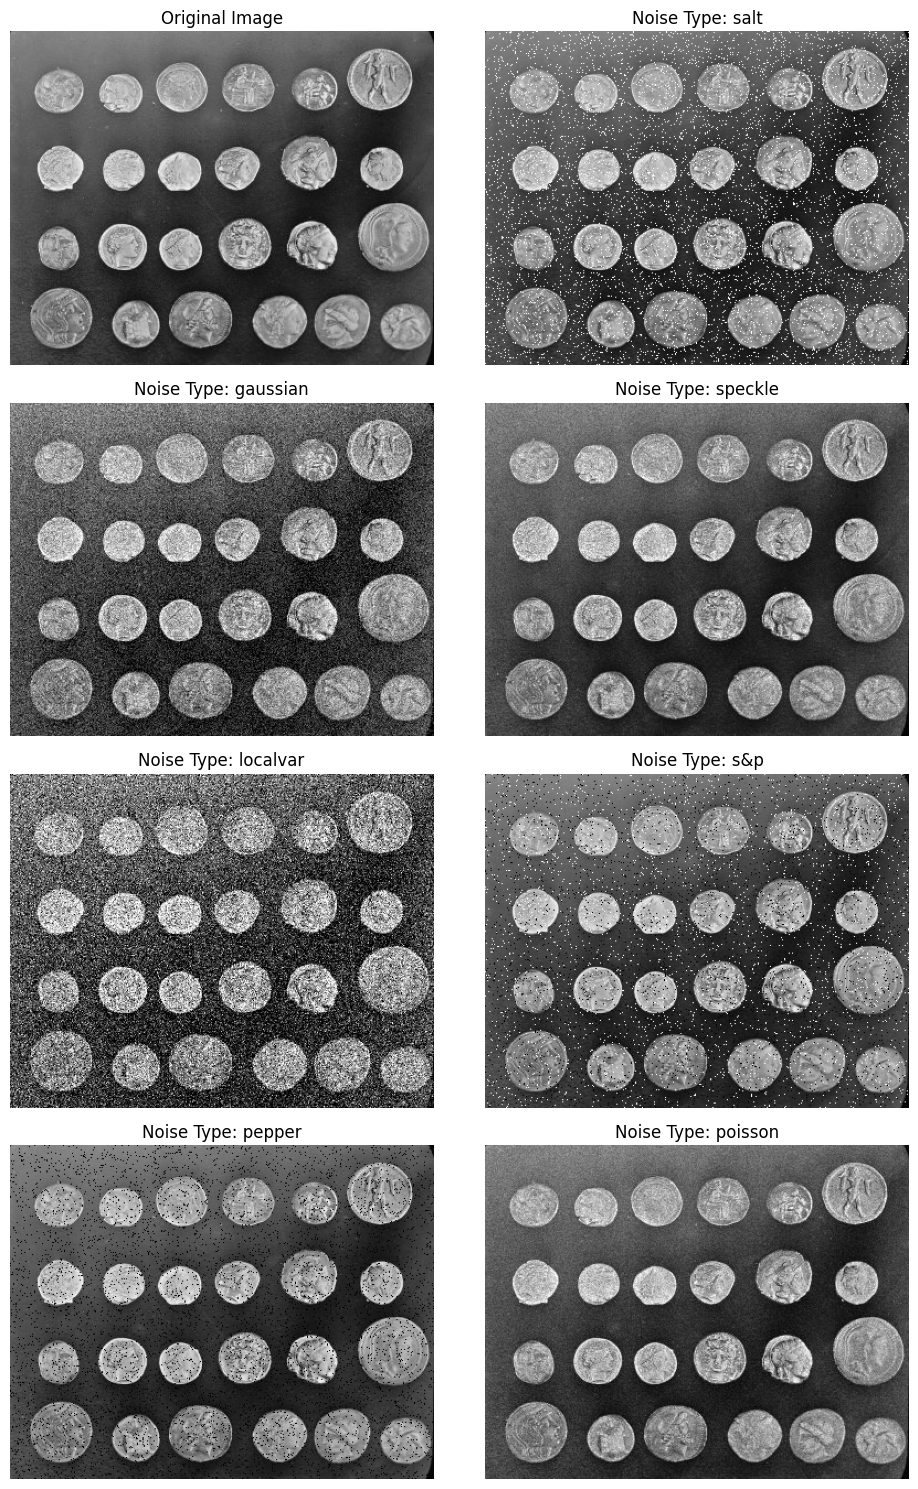

In [6]:
noise_types = ['salt', 'gaussian', 'speckle', 'localvar', 's&p', 'pepper', 'poisson']

fig, axes = plt.subplots(4, 2, figsize=(10, 15))

# Show original image in top-left
axes[0, 0].imshow(coins, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

for i, noise_type in enumerate(noise_types):
    row = (i + 1) // 2
    col = (i + 1) % 2

    # localvar needs a spatial variance map
    if noise_type == 'localvar':
        local_variance = np.random.rand(*coins.shape) * 0.1
        noisy_image = random_noise(coins, mode='gaussian', var=local_variance)
    else:
        noisy_image = random_noise(coins, mode=noise_type)

    axes[row, col].imshow(noisy_image, cmap='gray')
    axes[row, col].set_title(f'Noise Type: {noise_type}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

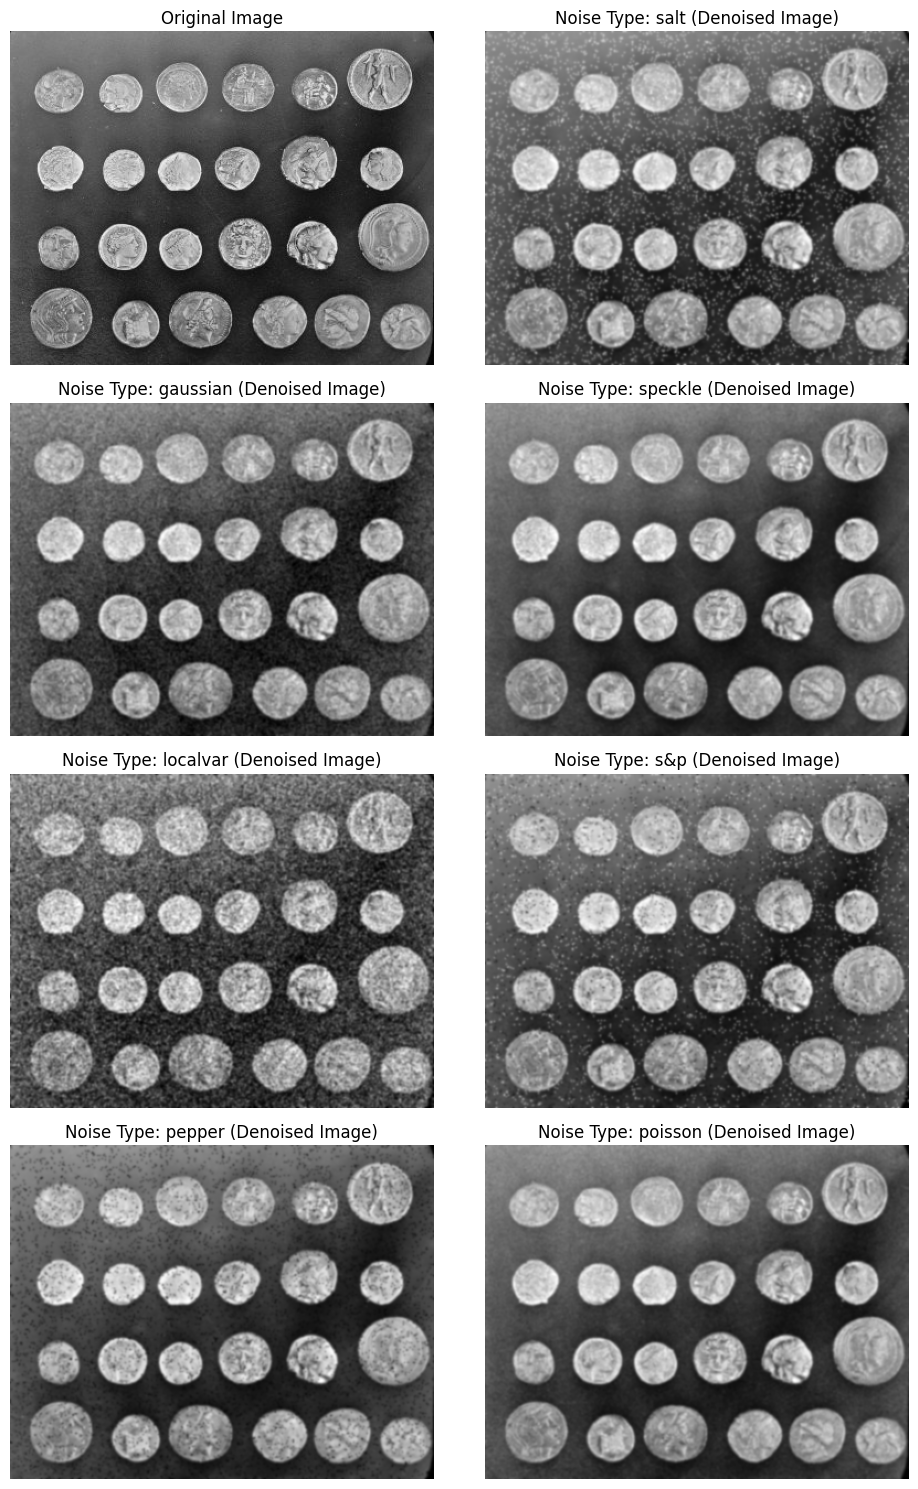

In [9]:
noise_types = ['salt', 'gaussian', 'speckle', 'localvar', 's&p', 'pepper', 'poisson']

fig, axes = plt.subplots(4, 2, figsize=(10, 15))

# Show original image in top-left
axes[0, 0].imshow(coins, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

for i, noise_type in enumerate(noise_types):
    row = (i + 1) // 2
    col = (i + 1) % 2

    # localvar needs a spatial variance map
    if noise_type == 'localvar':
        local_variance = np.random.rand(*coins.shape) * 0.1
        noisy_image = random_noise(coins, mode='gaussian', var=local_variance)
    else:
        noisy_image = random_noise(coins, mode=noise_type)

    # Apply Gaussian filter to smooth out noise
    denoised_image = gaussian(noisy_image, sigma=1)

    axes[row, col].imshow(denoised_image, cmap='gray')
    axes[row, col].set_title(f'Noise Type: {noise_type} (Denoised Image)')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

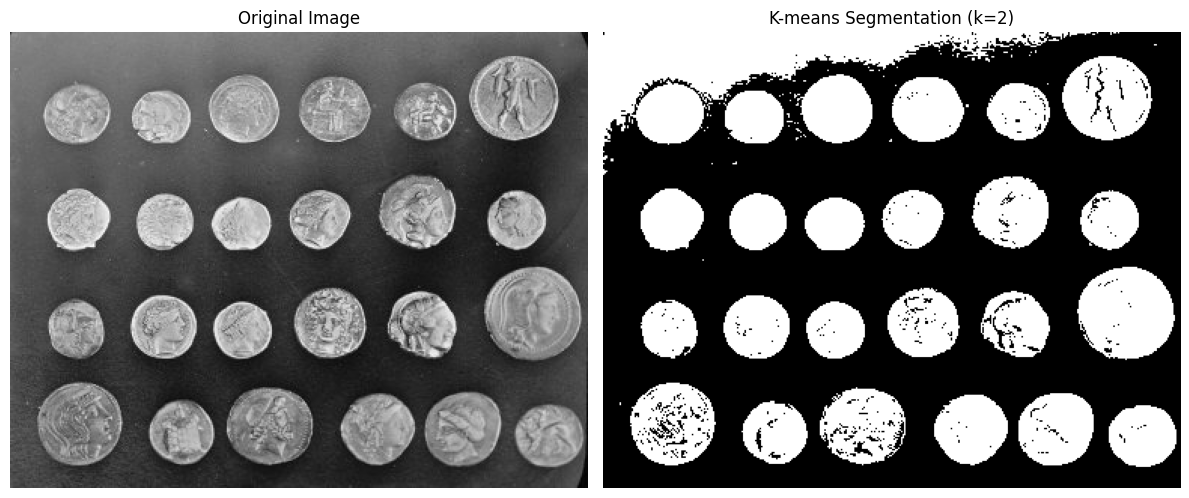

In [8]:
from sklearn.cluster import KMeans

# Reshape image to 1D array of pixels
image_2D = coins.reshape((-1, 1))

# Apply K-means with k=2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2D)

# Reshape labels back to image dimensions
segmented_image = kmeans.labels_.reshape(coins.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
ax = axes.ravel()

ax[0].imshow(coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].set_axis_off()

ax[1].imshow(segmented_image, cmap='gray')
ax[1].set_title('K-means Segmentation (k=2)')
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

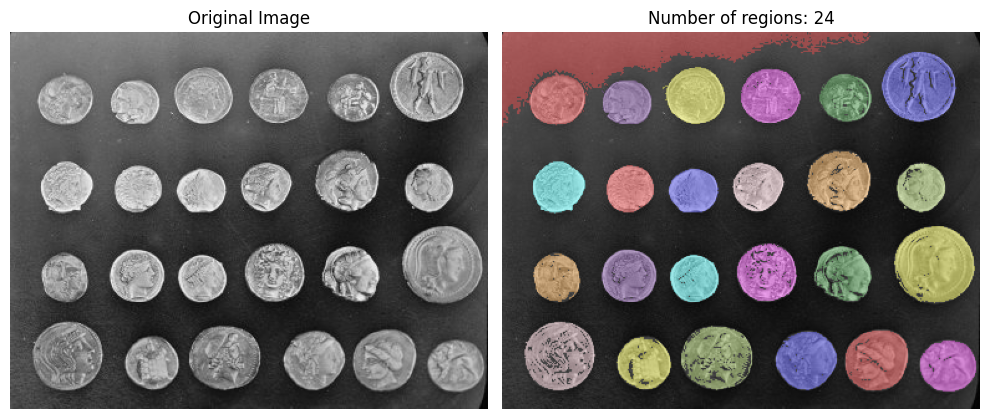

Number of coins in the image: 24


In [11]:
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# Otsu threshold and label
thresh = threshold_otsu(coins)
bw = coins > thresh
label_image, nregions = label(bw, return_num=True)

# Remove small regions using regionprops + area filtering (from doc)
props = regionprops(label_image)
for p in props:
    if p.area < 100:
        label_image[label_image == p.label] = 0

label_image, num_coins = label(label_image, return_num=True)
image_label_overlay = label2rgb(label_image, image=coins)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes.ravel()

ax[0].imshow(coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].set_axis_off()

ax[1].imshow(image_label_overlay, cmap=plt.cm.jet)
ax[1].set_title('Number of regions: {}'.format(num_coins))
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

print('Number of coins in the image: {}'.format(num_coins))

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  

    label    area  axis_major_length  orientation
0       1  8792.0         292.106573    -1.423583
1       2  2459.0          59.966495     1.552547
2       3  1687.0          47.569623     1.330279
3       4  1631.0          47.608317     1.560757
4       5  1194.0          41.353879     1.376770
5       6  1135.0          40.092938     1.434892
6       7  1836.0          51.388453     1.532671
7       8  1325.0          42.451724    -0.883311
8       9  1203.0          40.921169    -1.034534
9      10  1137.0          39.868831    -0.855962
10     11  1129.0          39.179294    -0.923138
11     12  1104.0          39.634983    -1.500398
12     13  3062.0          64.327036     1.375045
13     14  1634.0          48.451550    -1.471790
14     15  1353.0          47.299344     0.944604
15     16  1461.0          44.279748     1.510757
16     17  1101.0          37.968976     0.716816
17     18  1148.0          39.093268     1.512176
18     19  2111.0          58.136960    -1.105450


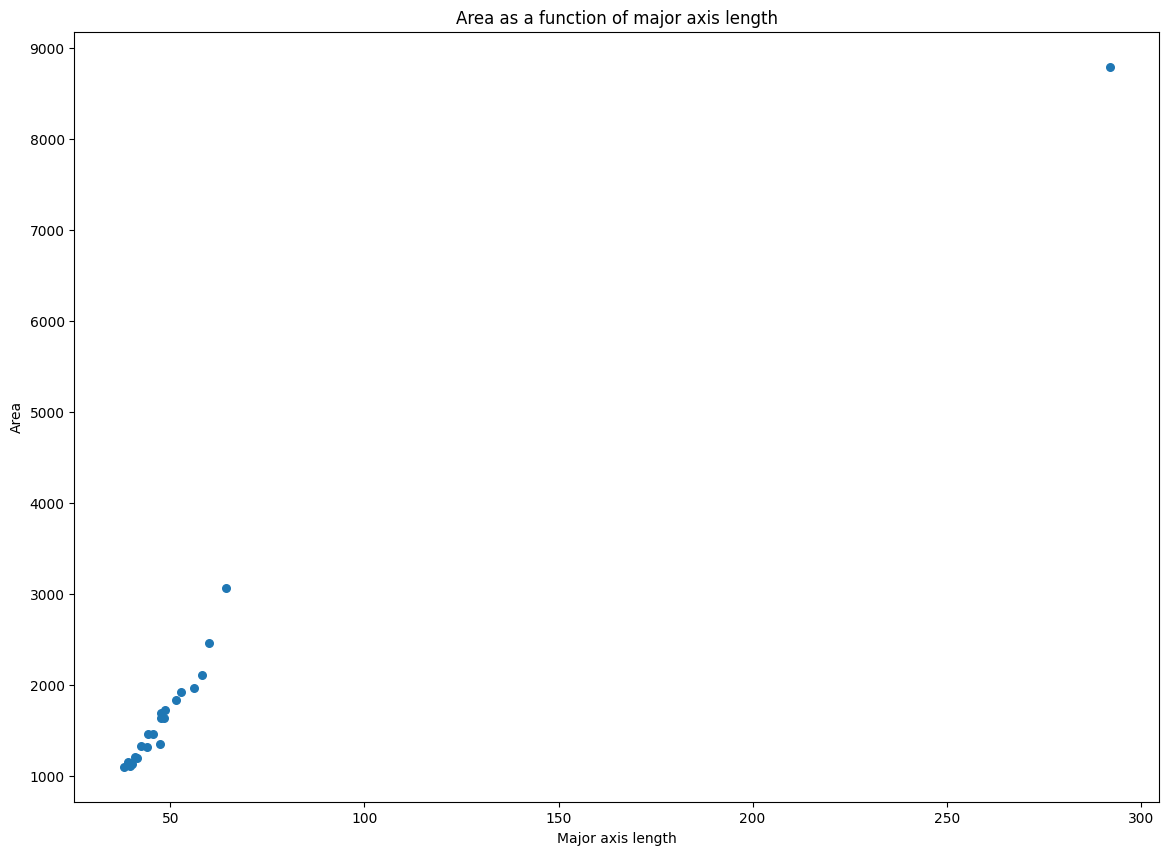

In [19]:
from skimage.measure import regionprops_table
import pandas as pd

# Extract regional properties for each coin
props_table = regionprops_table(label_image, properties=['label', 'area', 'axis_major_length', 'orientation'])
df = pd.DataFrame(props_table)
print(df)

# Report average values
print('Average area: {}'.format(df['area'].mean()))
print('Average major axis length: {}'.format(df['axis_major_length'].mean()))
print('Average orientation: {}'.format(df['orientation'].mean()))

# Scatterplot area vs major axis length
fig = plt.figure(figsize=(14, 10))
plt.scatter(df['axis_major_length'], df['area'], s=30, marker='o')
plt.xlabel('Major axis length')
plt.ylabel('Area')
plt.title('Area as a function of major axis length')
plt.show()

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [20]:
# Extract area and filter regions with area > 1750
features = np.zeros((num_coins, 1))
props = regionprops(label_image)

for i in range(0, num_coins):
    features[i, 0] = props[i].area

ind_large = np.where(features[:, 0] > 1750)
ind_large_regions = np.array(ind_large) + 1

print('There are {} coins with area greater than 1750 pixels'.format(len(ind_large_regions[0])))
print('Large coin regions: {}'.format(ind_large_regions))

There are 7 coins with area greater than 1750 pixels
Large coin regions: [[ 1  2  7 13 19 20 21]]


##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

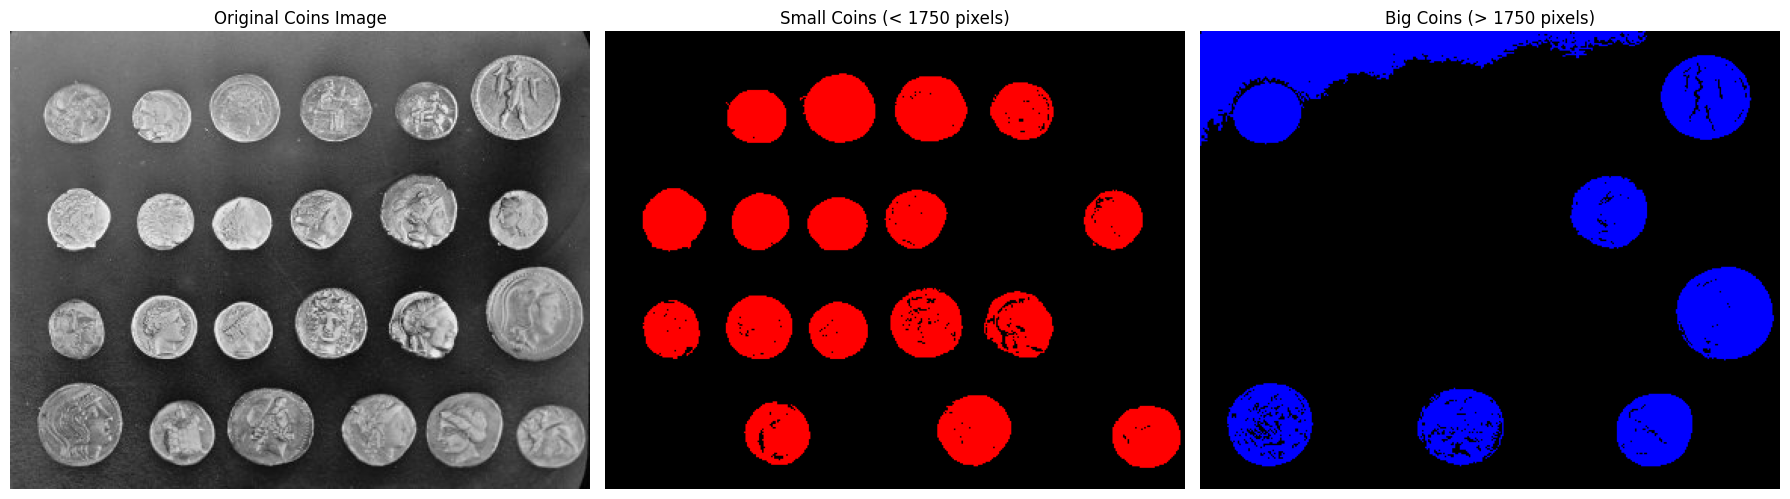

In [22]:
from skimage.measure import regionprops

# Create blank RGB images for small and big coins
small_coins_img = np.zeros((*coins.shape, 3), dtype=np.uint8)
big_coins_img = np.zeros((*coins.shape, 3), dtype=np.uint8)

# Loop through regions and paint them red or blue depending on area threshold
area_threshold = 1750
props = regionprops(label_image)

for p in props:
    coin_mask = label_image == p.label
    if p.area < area_threshold:
        small_coins_img[coin_mask] = [255, 0, 0]  # small coins red
    else:
        big_coins_img[coin_mask] = [0, 0, 255]  # big coins blue

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(coins, cmap='gray')
ax[0].set_title('Original Coins Image')
ax[0].set_axis_off()

ax[1].imshow(small_coins_img)
ax[1].set_title('Small Coins (< 1750 pixels)')
ax[1].set_axis_off()

ax[2].imshow(big_coins_img)
ax[2].set_title('Big Coins (> 1750 pixels)')
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

Segmenting an RGB image with unsupervised clustering starts by reshaping the image so that each pixel becomes a data point defined by its RGB values. From there, a clustering algorithm groups pixels with similar colors together.
Gaussian Mixture Models treat pixel colors as coming from a mix of Gaussian distributions, which tends to produce smoother, softer boundaries between regions. The number of components can be chosen automatically using BIC, which picks the model that best fits the data without overfitting.
The results show that the choice of algorithm has a real impact on the segmentation output. GMM works well when color regions blend naturally into each other, making it a good fit for images with gradual transitions in tone or lighting.

Best number of components: 5


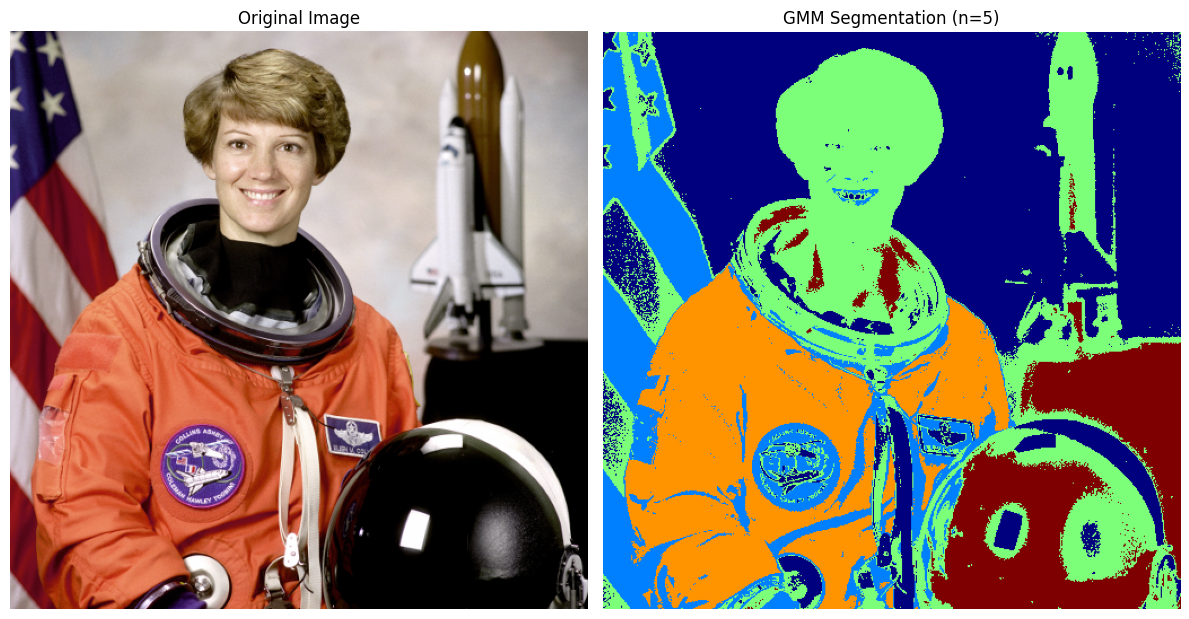

In [23]:
from sklearn.mixture import GaussianMixture
from skimage import data
from skimage.color import rgb2gray

# Load RGB image and reshape so each pixel is represented by its RGB values
image = data.astronaut()
image_2D = image.reshape((-1, 3))

# Use BIC to choose the best number of Gaussian components
bic_scores = []
n_components_range = range(2, 6)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n)
    gmm.fit(image_2D)
    bic_scores.append(gmm.bic(image_2D))

# Best number of components = lowest BIC score
best_n = n_components_range[np.argmin(bic_scores)]
print('Best number of components: {}'.format(best_n))


gmm = GaussianMixture(n_components=best_n)
gmm.fit(image_2D)
labels = gmm.predict(image_2D)


segmented_image = labels.reshape(image.shape[:2])

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].set_axis_off()

ax[1].imshow(segmented_image, cmap=plt.cm.jet)
ax[1].set_title('GMM Segmentation (n={})'.format(best_n))
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

## 10. Extract the main texture features of this image

In [25]:
from skimage.feature.texture import graycomatrix, graycoprops
from skimage.measure import regionprops
import pandas as pd
from skimage import img_as_ubyte

# Convert to grayscale uint8 and segment
IG = img_as_ubyte(rgb2gray(image))
thresh = threshold_otsu(IG)
bw = IG > thresh
label_image, nregions = label(bw, return_num=True)

props = regionprops(label_image, intensity_image=IG)
nregions = len(props)

# Extract texture features per region
iregion = 0
props_texture = np.zeros((nregions, 6))

for p in props:
    minr, minc, maxr, maxc = p.bbox
    I = IG[minc:maxc, minr:maxr]
    g = graycomatrix(I, [1], [0], levels=None, normed=True, symmetric=True)
    props_texture[iregion, 0] = graycoprops(g, 'contrast')
    props_texture[iregion, 1] = graycoprops(g, 'dissimilarity')
    props_texture[iregion, 2] = graycoprops(g, 'homogeneity')
    props_texture[iregion, 3] = graycoprops(g, 'ASM')
    props_texture[iregion, 4] = graycoprops(g, 'energy')
    props_texture[iregion, 5] = graycoprops(g, 'correlation')
    iregion = iregion + 1

df = pd.DataFrame(props_texture, columns=['Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy', 'Correlation'])
df.to_excel("Texture_features.xlsx", index=False)
df

/tmp/ipykernel_1510/2549672745.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 0] = graycoprops(g, 'contrast')
/tmp/ipykernel_1510/2549672745.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 1] = graycoprops(g, 'dissimilarity')
/tmp/ipykernel_1510/2549672745.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 2] = graycoprops(g, 'homogeneity')
/tmp/ipykernel_1510/2549672745.py:26: Deprec

,Contrast,Dissimilarity,Homogeneity,ASM,Energy,Correlation
0,309.056856,11.050167,0.173340,0.006007,0.077503,0.979577
1,239.205476,6.942702,0.339748,0.011388,0.106714,0.978941
2,319.664474,12.585526,0.109961,0.003852,0.062066,0.889126
3,150.723684,7.407895,0.210126,0.005194,0.072069,0.403656
4,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...
144,1409.950000,20.650000,0.600492,0.370000,0.608276,0.302788
145,6805.000000,82.000000,0.000154,0.250000,0.500000,-0.958555
146,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
147,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


## Personal discussion

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)

This course gave me a new perspective in the field of AI. Having a hands-on approach by learning Computer Vision in a practical way has helped me understand the subject much better than I expected. Working directly with real images and seeing the results of your code immediately makes a huge difference compared to just reading about it. The way the course was structured made even complex topics feel approachable. I really appreciated the teaching style and the effort to show us how these tools are actually used in the real world. Hoping to continue learning more about this in the future.

Martin